In [1]:
# Standard Package
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# datetime Package
from datetime import datetime

# Serialization Package
import joblib

# Classifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve

In [2]:
data = joblib.load("../data/processed/cleaned_data.pkl")
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total_Price
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


- Let's Group the data by invoice.

In [3]:
groupby_invoice = data.groupby(['Invoice','InvoiceDate', 'Customer ID'])['Total_Price'].sum()
groupby_invoice = groupby_invoice.sort_values(ascending=False).reset_index()
groupby_invoice.head()

,Invoice,InvoiceDate,Customer ID,Total_Price
0,493819,2010-01-07 12:34:00,14156,44051.60
1,524181,2010-09-27 16:59:00,17450,33167.80
2,526934,2010-10-14 09:46:00,18102,26007.08
3,515944,2010-07-15 15:29:00,18102,22863.36
4,517731,2010-08-01 13:31:00,18102,21984.00


- To see how often customers are doing transaction, lets calculate each customer transaction interpurchase time(IPT).

In [4]:
groupby_invoice = groupby_invoice.sort_values(['Customer ID', 'InvoiceDate'])

groupby_invoice['IPT'] = groupby_invoice.groupby('Customer ID')['InvoiceDate'].diff().dt.days

groupby_invoice.head()

,Invoice,InvoiceDate,Customer ID,Total_Price,IPT
17989,491725,2009-12-14 08:34:00,12346,45.0,NaN
18532,491742,2009-12-14 11:00:00,12346,22.5,0.0
18533,491744,2009-12-14 11:02:00,12346,22.5,0.0
18525,492718,2009-12-18 10:47:00,12346,22.5,3.0
19236,492722,2009-12-18 10:55:00,12346,1.0,0.0


In [5]:
cust_ipt = groupby_invoice.groupby('Customer ID')['IPT'].median()

# median IPT overall
median_ipt = cust_ipt.median()

median_ipt

44.0

- The median interpurchase time is 44 days $\approx$ 6 weeks 
- Using this as a reference, let's define a 12-week (2 cycles) Observation Window (OW) and a 6-week Performance Window (PW) for the churn prediction.
- This means that the 12 week window will be used to predict whether the customer will churn in the following 6 week period.
- In real production systems, the current week’s transaction data is incomplete (still ongoing).  Therefore, we cannot safely use it in the observation window.
- So, set a 1-week gap period.


In [6]:
groupby_invoice['Week'] = groupby_invoice['InvoiceDate'].dt.isocalendar().week
groupby_invoice['Year'] = groupby_invoice['InvoiceDate'].dt.year

# Validation
groupby_invoice.head()

,Invoice,InvoiceDate,Customer ID,Total_Price,IPT,Week,Year
17989,491725,2009-12-14 08:34:00,12346,45.0,NaN,51,2009
18532,491742,2009-12-14 11:00:00,12346,22.5,0.0,51,2009
18533,491744,2009-12-14 11:02:00,12346,22.5,0.0,51,2009
18525,492718,2009-12-18 10:47:00,12346,22.5,3.0,51,2009
19236,492722,2009-12-18 10:55:00,12346,1.0,0.0,51,2009


In [7]:
groupby_invoice = groupby_invoice.sort_values(['InvoiceDate', 'Week'])

# Validation
groupby_invoice.head()

,Invoice,InvoiceDate,Customer ID,Total_Price,IPT,Week,Year
4485,489434,2009-12-01 07:45:00,13085,505.30,NaN,49,2009
14907,489435,2009-12-01 07:46:00,13085,145.80,0.0,49,2009
3153,489436,2009-12-01 09:06:00,13078,630.33,NaN,49,2009
9031,489437,2009-12-01 09:08:00,15362,310.75,NaN,49,2009
365,489438,2009-12-01 09:24:00,18102,2286.24,NaN,49,2009


- Our Data is starting from  1 Desember 2009 (week 49), set it to be the first week (- 48).

In [8]:
groupby_invoice['WeekIndex'] = (groupby_invoice['Year'] - groupby_invoice['Year'].min()) * 52 + groupby_invoice['Week'] - 48

display(groupby_invoice.head())

# Check the number of week available in the data
print("Number of weeks in the Data:", groupby_invoice['WeekIndex'].max())

,Invoice,InvoiceDate,Customer ID,Total_Price,IPT,Week,Year,WeekIndex
4485,489434,2009-12-01 07:45:00,13085,505.30,NaN,49,2009,1
14907,489435,2009-12-01 07:46:00,13085,145.80,0.0,49,2009,1
3153,489436,2009-12-01 09:06:00,13078,630.33,NaN,49,2009,1
9031,489437,2009-12-01 09:08:00,15362,310.75,NaN,49,2009,1
365,489438,2009-12-01 09:24:00,18102,2286.24,NaN,49,2009,1


Number of weeks in the Data: 53


## Creating Weekly Log ( 1= transacting, 0 = not transacting)

In [9]:
unique_customers = groupby_invoice['Customer ID'].unique()

# Create weeklylog dataframe consist of zeros
weekly_log = pd.DataFrame(0, index = unique_customers, columns = np.arange(1,54))

weekly_log.head()

,1,2,3,4,5,6,7,8,9,10,...,44,45,46,47,48,49,50,51,52,53
13085,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13078,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15362,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18102,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12682,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
# Fill the data
for cust, group in groupby_invoice.groupby('Customer ID'):
    weeks = group['WeekIndex'].unique()
    weekly_log.loc[cust, weeks] = 1

#Validation
weekly_log.head()

,1,2,3,4,5,6,7,8,9,10,...,44,45,46,47,48,49,50,51,52,53
13085,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
13078,1,1,1,0,1,0,1,0,1,0,...,0,1,0,1,0,1,1,1,1,1
15362,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18102,1,1,1,1,1,1,0,0,1,0,...,0,1,0,0,0,1,1,0,0,1
12682,1,1,0,1,0,1,0,0,1,1,...,0,1,0,0,0,1,1,0,1,1


In [11]:
weekly_log.shape

(4314, 53)

- We have 4314 Customer and 53 weeks of transaction log
- Let's also make the spending log of each transaction

In [12]:
def create_weekly_spending_log(df):
    df = df.copy()
    df["WeekIndex"] = df["InvoiceDate"].dt.isocalendar().week

    # pivot -> customers as rows, week as columns, values = total spending
    spending_log = df.pivot_table(
        index="Customer ID",
        columns="Week",
        values="Total_Price",
        aggfunc="sum",
        fill_value=0
    )
    return spending_log

In [13]:
spending_log = create_weekly_spending_log(groupby_invoice)
spending_log.head()

Week,1,2,3,4,5,6,7,8,9,10,...,43,44,45,46,47,48,49,50,51,52
Customer ID,,,,,,,,,,,,,,,,,,,,,
12346,45.0,22.5,22.5,0.0,0.0,0.0,0.0,0.0,27.05,0.0,...,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.0,113.5,0.0
12347,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,611.53,0.0,0.0,0.0,0.0,0.00,711.79,0.0,0.0,0.0
12348,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0
12349,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,1402.62,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0
12351,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,0.00,0.0,0.0,0.0,0.0,300.93,0.00,0.0,0.0,0.0


In [14]:
# Save the Data
joblib.dump(weekly_log,"../data/processed/weekly_transaction_log.pkl")
joblib.dump(spending_log,"../data/processed/weekly_spending_log.pkl")

['../data/processed/weekly_spending_log.pkl']

- Generate RFM+T features from the past 12-week to predict the following 6-week
- Churn label: not doing any transaction in the 6-week performance window.

In [15]:
def recency(row):
    """
    Weeks since last purchase in observation window.
    If no purchase → Recency = full OW length
    """
    if row.sum() == 0:
        return len(row)
    last_active_idx = (row > 0).values.nonzero()[0][-1]    # getting latest purchase week
    return len(row) - last_active_idx -1              # -1 because the index start from 0


def frequency(subset):
    return subset.sum(axis=1)


def tenure(first_purchase_week_series, ow_end_week):
    """
    Tenure = How long customer has been "alive" until OW_End
    if customer havent done any transaction → Tenure = 0 
    """
    tenure_val = ow_end_week - first_purchase_week_series + 1
    return tenure_val.clip(lower=0)   


def churn_label(log, pw_start_idx, pw_end_idx):
    pw_subset = log.iloc[:, pw_start_idx:pw_end_idx + 1]
    return (pw_subset.sum(axis=1) == 0).astype(int)


def compute_window(log, spending_log, ow_start_idx, ow_end_idx, pw_start_idx, pw_end_idx,
                   ow_start_week, ow_end_week, pw_start_week, pw_end_week):
    """
    Hitung semua fitur untuk satu window
    """
    # Observation Window
    log_ow = log.iloc[:, ow_start_idx:ow_end_idx + 1]
    spending_ow = spending_log.iloc[:, ow_start_idx:ow_end_idx + 1]

    # RFM
    freq = frequency(log_ow)
    rec = log_ow.apply(recency, axis=1)
    monetary = spending_ow.sum(axis=1)
    aov = monetary / freq.replace(0, np.nan)
    aov = aov.fillna(0)

    # First purchase week 
    first_purchase_week = (log > 0).idxmax(axis=1).astype(int)

    # Tenure 
    tenure_val = tenure(first_purchase_week, ow_end_week)

    # Churn label
    churn = churn_label(log, pw_start_idx, pw_end_idx)

    # Build DataFrame
    df = pd.DataFrame({
        'Customer'       : log.index,
        'Window_End'     : ow_end_week,
        'OW_Start_Week'  : ow_start_week,
        'OW_End_Week'    : ow_end_week,
        'PW_Start_Week'  : pw_start_week,
        'PW_End_Week'    : pw_end_week,
        'Recency'        : rec.values,
        'Frequency'      : freq.values,
        'Monetary'       : monetary.values,
        'AOV'            : aov.values,
        'Tenure'         : tenure_val.values,
        'Churn'          : churn.values
    })
    return df


def sliding_rfm_churn(log, spending_log,
                      ow_weeks=12,
                      pw_weeks=6,
                      gap_weeks=1):

    total_weeks = log.shape[1]      # 53
    records = []

    # 53 - 1 - 6  = 46
    max_ow_end_week = total_weeks - gap_weeks - pw_weeks

    for ow_end_week in range(ow_weeks, max_ow_end_week + 1):   # [12 to 46 +1) 
        ow_start_week = ow_end_week - ow_weeks + 1             # week 1, 2, ...

        # (index 0 = week 1)
        ow_start_idx = ow_start_week - 1
        ow_end_idx   = ow_end_week - 1

        # Prediction Window 
        pw_start_week = ow_end_week + gap_weeks + 1 # 12 + 1 + 1 = 14 (start)
        pw_end_week   = pw_start_week + pw_weeks - 1 # 14 + 6 - 1 = 19 (end)

        # (index 0 = week 1)
        pw_start_idx = pw_start_week - 1
        pw_end_idx   = pw_end_week - 1

        if pw_end_idx >= total_weeks:
            continue

        window_df = compute_window(
            log=log,
            spending_log=spending_log,
            ow_start_idx=ow_start_idx,
            ow_end_idx=ow_end_idx,
            pw_start_idx=pw_start_idx,
            pw_end_idx=pw_end_idx,
            ow_start_week=ow_start_week,
            ow_end_week=ow_end_week,
            pw_start_week=pw_start_week,
            pw_end_week=pw_end_week
        )
        records.append(window_df)

    if not records:
        raise ValueError("No windows generated!")

    return pd.concat(records, ignore_index=True)

In [16]:
rfm_churn_all = sliding_rfm_churn(weekly_log, spending_log, ow_weeks=12,
                      pw_weeks=6,
                      gap_weeks=1)


# Validation
rfm_churn_all.head()


,Customer,Window_End,OW_Start_Week,OW_End_Week,PW_Start_Week,PW_End_Week,Recency,Frequency,Monetary,AOV,Tenure,Churn
0,13085,12,1,12,14,19,4,2,117.05,29.2625,12,1
1,13078,12,1,12,14,19,1,7,0.00,0.0000,12,0
2,15362,12,1,12,14,19,11,1,0.00,0.0000,12,1
3,18102,12,1,12,14,19,0,9,0.00,0.0000,12,0
4,12682,12,1,12,14,19,0,7,0.00,0.0000,12,0


- We can see from the first row that the features is extracted from week 1 to 12 and the label from week 14-19 with week 13 as the gap week.
- Now, let's see the churn proportion of our data

In [17]:
rfm_churn_all['Churn'].value_counts(normalize=True)

Churn
1    0.674561
0    0.325439
Name: proportion, dtype: float64

- We don't need to use resampling techniques because the proportions aren't severely imbalanced.
- We need to split the data to test and train set.
- Since we need at least 19 weeks of data to create a set, then the training set should end on week 53 - 19  = 34 and test set start on week 35.

In [18]:
rfm_churn_test = rfm_churn_all[rfm_churn_all['Window_End']>= 35]
rfm_churn_train = rfm_churn_all[~(rfm_churn_all['Window_End']>= 35)]

## Modelling

Let's fit our training data to the classifier. We'll start with logistic regression.

### Logistic Regression

In [19]:
X_train = rfm_churn_train[['Frequency','Recency','Monetary','Tenure']]  # feature
y_train = rfm_churn_train['Churn']                           # target

model_logreg = LogisticRegression()
model_logreg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


- to be able to fully assess the model's performance, let's create  an evaluation function. 

In [20]:
def eval_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc_score = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
        
    print("Accuracy      :", acc)
    print("Precision     :", prec)
    print("Recall        :", rec)
    print("F1-score      :", f1)
    print("ROC-AUC       :", auc_score)
    
    # --- Confusion Matrix ---
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.gca().set_xticklabels(["Not Churn (0)", "Churn (1)"])
    plt.gca().set_yticklabels(["Not Churn (0)", "Churn (1)"])
    plt.show()

Accuracy      : 0.7528773860635746
Precision     : 0.7544055515422167
Recall        : 0.9706785342083768
F1-score      : 0.8489850216791486
ROC-AUC       : 0.6679770526047065


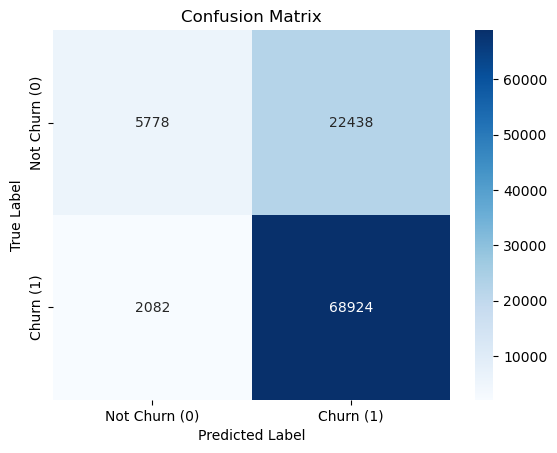

In [21]:
y_pred = model_logreg.predict(X_train)          
y_prob = model_logreg.predict_proba(X_train)[:,1]  

eval_metrics(y_train, y_pred, y_prob)

- To tune the prediction threshold, let's create a function to visualise the ROC-AUC curve and the optimal threshold point.
- Let's evaluate these 2 threshold tuning strategy:
    - threshold that maximises the F1 score
    - threshold that closest to (0, 1).

In [22]:
def optimal_threshold(y_true, y_prob, show_plot=True):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    
    #  ROC Curve
    fpr, tpr, roc_thresh = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    
    #  Precision-Recall Curve + Max F1
    precision, recall, pr_thresh = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * recall * precision / (recall + precision + 1e-12)
    best_f1_idx = np.argmax(f1_scores)
    thresh_f1 = pr_thresh[best_f1_idx]
    best_f1 = f1_scores[best_f1_idx]
    

    #  Closest to top-left corner (0,1) 
    distance = np.sqrt(fpr**2 + (1 - tpr)**2)
    best_corner_idx = np.argmin(distance)
    thresh_corner = roc_thresh[best_corner_idx]
    dist_min = distance[best_corner_idx]

    # Print all the result
    print(f"ROC AUC Score: {auc}")

    print(f"Best Threshold (Max F1) {thresh_f1}")
    print(f"Best Threshold (Closest to (0,1)): {thresh_corner}")

    # Plotting
    fig, ax = plt.subplots(1, 1, figsize=(9, 7))

    ax.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.4f})', linewidth=2, color='darkorange')
    ax.plot([0, 1], [0, 1], '--', color='gray', label='Random Classifier')


    # Closest to (0,1) 
    ax.scatter(fpr[best_corner_idx], tpr[best_corner_idx], 
               color='red', s=180, zorder=5, marker='X', edgecolors='black', linewidth=2,
               label=f'Closest to (0,1)\nThresh = {thresh_corner:.4f}')

    # Max F1 point 
    idx_f1_roc = np.argmin(np.abs(roc_thresh - thresh_f1))
    ax.scatter(fpr[idx_f1_roc], tpr[idx_f1_roc], 
               color='blue', s=120, zorder=5, marker='D',
               label=f'Max F1 (PR)\nThresh ≈ {thresh_f1:.4f}')


    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve', fontsize=14, pad=20)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)

    plt.tight_layout()
    plt.show()

    return thresh_f1, thresh_corner


ROC AUC Score: 0.6679770526047065
Best Threshold (Max F1) 0.3770395242420077
Best Threshold (Closest to (0,1)): 0.7169313717896574


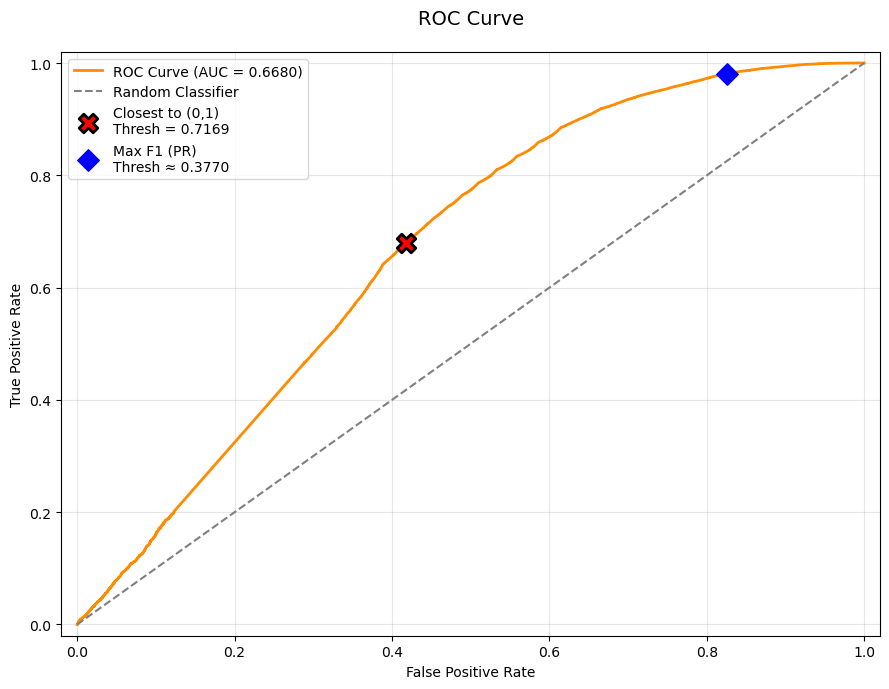

In [23]:
thresh_f1, thresh_corner = optimal_threshold(y_train, y_prob)

- Let's see how each threshold perform on the training data

Accuracy      : 0.751788917780331
Precision     : 0.7494674785377714
Recall        : 0.9811283553502521
F1-score      : 0.8497926323493535
ROC-AUC       : 0.6679770526047065


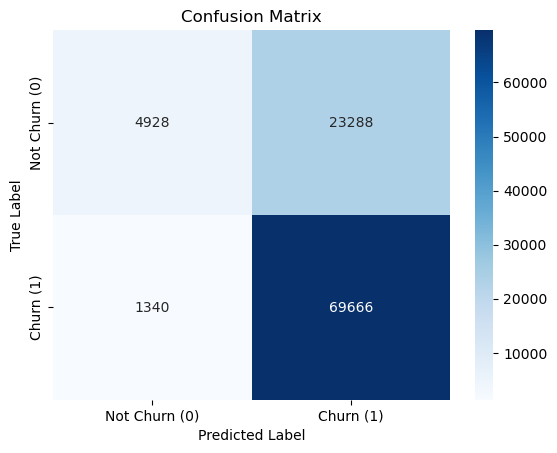

In [24]:
y_pred_f1 = (y_prob >= thresh_f1).astype(int)

eval_metrics(y_train, y_pred_f1, y_prob)

Accuracy      : 0.6519320312027574
Precision     : 0.8035220879523286
Recall        : 0.6798580401656198
F1-score      : 0.7365353513777425
ROC-AUC       : 0.6679770526047065


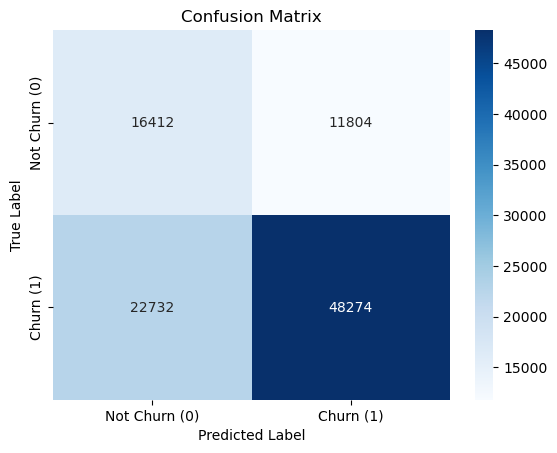

In [25]:
y_pred_corner = (y_prob >= thresh_corner).astype(int)

eval_metrics(y_train, y_pred_corner, y_prob)

- The threshold obtained by maximizing F1 yields a noticeably higher recall compared to the threshold from the closest-to-(0,1) method.
- Given that catching churned customers are more important than keeping the prediction list perfectly clean (precision), we should go with the Max F1 threshold

Accuracy      : 0.6356243239066605
Precision     : 0.6247008137865007
Recall        : 0.9730597160085587
F1-score      : 0.7609040092276881
ROC-AUC       : 0.565838093017762


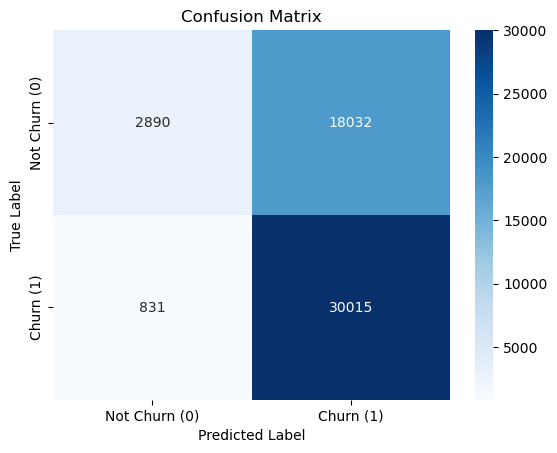

In [26]:
# Testing it on the test set
best_threshold = thresh_f1
X_test = rfm_churn_test[['Frequency','Recency','Monetary','Tenure']]
y_test = rfm_churn_test['Churn'] 
        
y_prob_test = model_logreg.predict_proba(X_test)[:,1] 
y_pred_test = (y_prob_test >= best_threshold).astype(int)

eval_metrics(y_test, y_pred_test, y_prob_test)


In [27]:
joblib.dump(
    {"model": model_logreg, "threshold": best_threshold}, 
    '../models/logreg_and_threshold.pkl'
)

['../models/logreg_and_threshold.pkl']

- Now let's try it on other models (XGBoost, Lightgbm, CatBoost).

## XGBOOST

In [28]:
model_xgb = XGBClassifier()
model_xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


Accuracy      : 0.7744149482977566
Precision     : 0.777931475998308
Recall        : 0.9583415486015266
F1-score      : 0.858763621678582
ROC-AUC       : 0.732851236246495


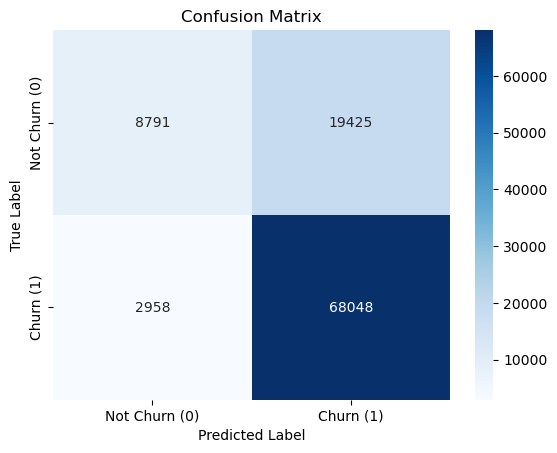

In [29]:
y_pred_xgb = model_xgb.predict(X_train)
prob_xgb = model_xgb.predict_proba(X_train)

y_prob_xgb = prob_xgb[:,1]

eval_metrics(y_train, y_pred_xgb, y_prob_xgb)

ROC AUC Score: 0.732851236246495
Best Threshold (Max F1) 0.4672432243824005
Best Threshold (Closest to (0,1)): 0.7627625465393066


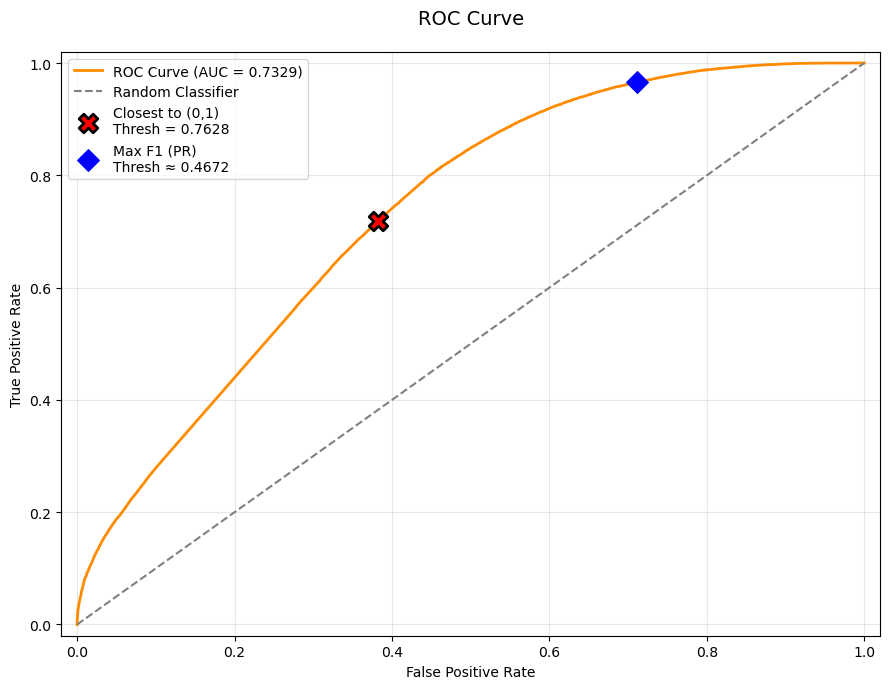

In [30]:
thresh_f1_xgb, thresh_corner_xgb = optimal_threshold(y_train, y_prob_xgb)

Accuracy      : 0.7733466368345729
Precision     : 0.7737145565121238
Recall        : 0.9657212066585922
F1-score      : 0.8591206078943577
ROC-AUC       : 0.732851236246495


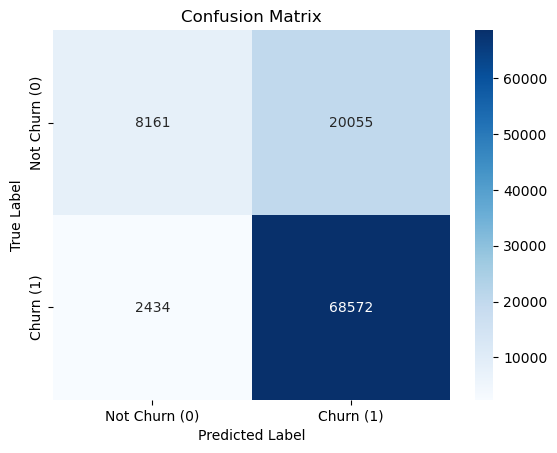

In [31]:
y_pred_f1_xgb = (y_prob_xgb >= thresh_f1_xgb).astype(int)

eval_metrics(y_train, y_pred_f1_xgb, y_prob_xgb)

Accuracy      : 0.6896555199451735
Precision     : 0.8254268835477867
Recall        : 0.7182350787257414
F1-score      : 0.7681092845147638
ROC-AUC       : 0.732851236246495


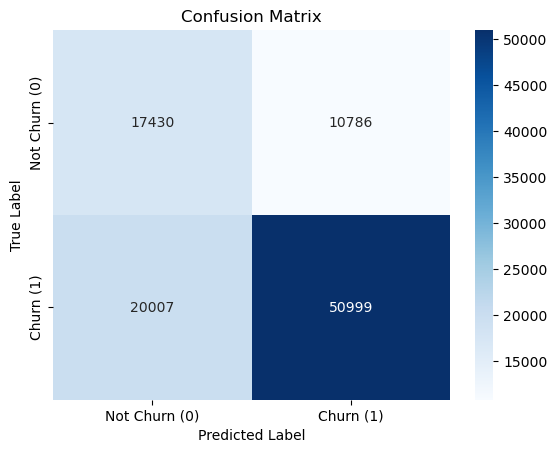

In [32]:
y_pred_corner_xgb = (y_prob_xgb >= thresh_corner_xgb).astype(int)

eval_metrics(y_train, y_pred_corner_xgb, y_prob_xgb)

Accuracy      : 0.6387343532684284
Precision     : 0.6340634107568666
Recall        : 0.9310121247487518
F1-score      : 0.7543670703196826
ROC-AUC       : 0.6143797975198997


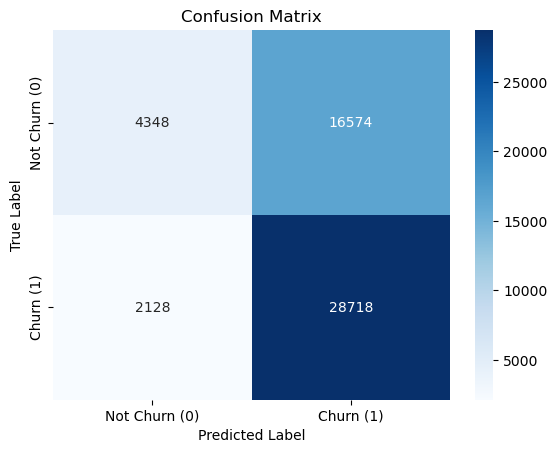

In [33]:
y_prob_test_xgb = model_xgb.predict_proba(X_test)[:,1] 
y_pred_test_xgb =  (y_prob_test_xgb >= thresh_f1_xgb).astype(int)

eval_metrics(y_test, y_pred_test_xgb, y_prob_test_xgb)

In [34]:
joblib.dump(
    {"model": model_xgb, "threshold": thresh_f1_xgb}, 
    '../models/xgb_and_threshold.pkl'
)

['../models/xgb_and_threshold.pkl']

## LGBM

In [35]:
model_lgbm = LGBMClassifier()
model_lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 71006, number of negative: 28216
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014242 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 316
[LightGBM] [Info] Number of data points in the train set: 99222, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.715628 -> initscore=0.922875
[LightGBM] [Info] Start training from score 0.922875


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


Accuracy      : 0.7659994759226785
Precision     : 0.7705695844185256
Recall        : 0.9583556319184294
F1-score      : 0.8542644806547993
ROC-AUC       : 0.7096146687700096


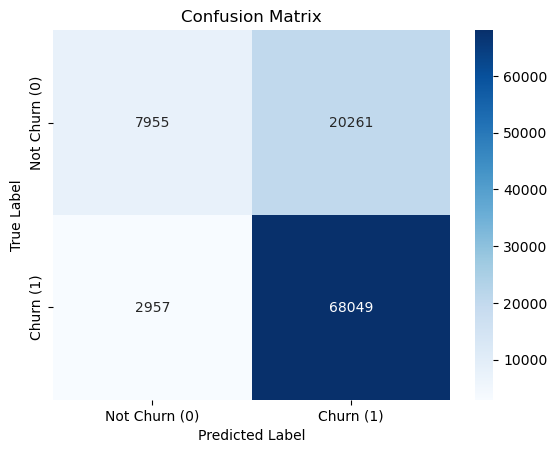

In [36]:
# Predictions
y_pred_lgbm = model_lgbm.predict(X_train)

# Churn Probabilty
prob_lgbm = model_lgbm.predict_proba(X_train) # Output : array([0.xxx, 0.xxx])
y_prob_lgbm = prob_lgbm[:,1] 

# Evaluation
eval_metrics(y_train, y_pred_lgbm, y_prob_lgbm)

ROC AUC Score: 0.7096146687700096
Best Threshold (Max F1) 0.4753843808635631
Best Threshold (Closest to (0,1)): 0.7733023483641149


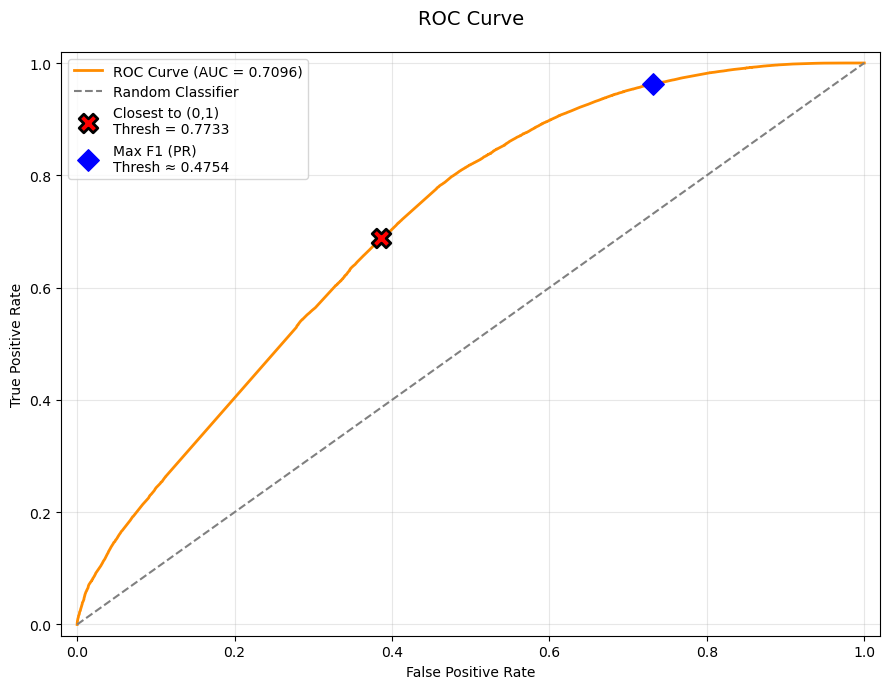

In [37]:
thresh_f1_lgbm, thresh_corner_lgbm = optimal_threshold(y_train, y_prob_lgbm)

Accuracy      : 0.7653947713208764
Precision     : 0.7680625449317038
Recall        : 0.962960876545644
F1-score      : 0.854539773792414
ROC-AUC       : 0.7096146687700096


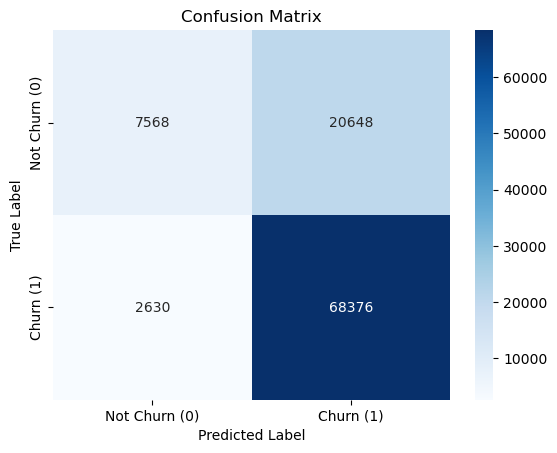

In [38]:
y_pred_f1_lgbm = (y_prob_lgbm >= thresh_f1_lgbm).astype(int)

eval_metrics(y_train, y_pred_f1_lgbm, y_prob_lgbm)

Accuracy      : 0.6671201951180182
Precision     : 0.8177087690531564
Recall        : 0.6882798636734924
F1-score      : 0.7474325740022788
ROC-AUC       : 0.7096146687700096


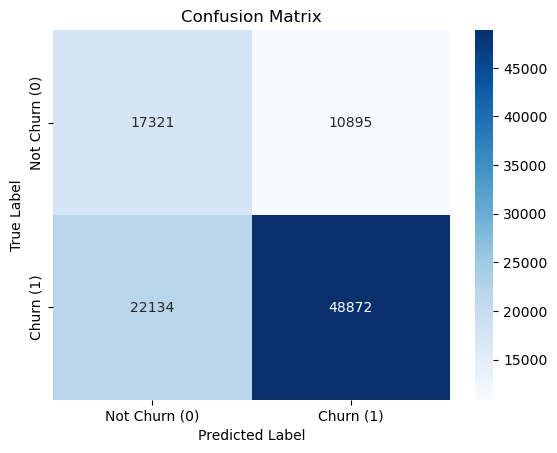

In [39]:
y_pred_corner_lgbm = (y_prob_lgbm >= thresh_corner_lgbm).astype(int)

eval_metrics(y_train, y_pred_corner_lgbm, y_prob_lgbm)

Accuracy      : 0.6443749034152372
Precision     : 0.6363118204138899
Recall        : 0.9409972119561694
F1-score      : 0.7592268054719992
ROC-AUC       : 0.6230423655378263


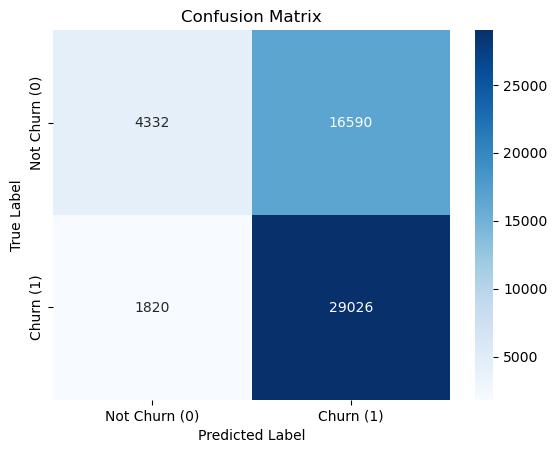

In [40]:
y_prob_test_lgbm = model_lgbm.predict_proba(X_test)[:,1] 
y_pred_test_lgbm = (y_prob_test_lgbm >= thresh_f1_lgbm).astype(int)

eval_metrics(y_test, y_pred_test_lgbm, y_prob_test_lgbm)

In [41]:
joblib.dump(
    {"model": model_lgbm, "threshold": thresh_f1_lgbm}, 
    '../models/lgbm_and_threshold.pkl'
)

['../models/lgbm_and_threshold.pkl']

## Catboost

In [42]:
model_cat = CatBoostClassifier(verbose=False)
model_cat.fit(X_train, y_train)

Accuracy      : 0.7726915401826208
Precision     : 0.7758471488431409
Recall        : 0.9596090471227784
F1-score      : 0.8579991185544292
ROC-AUC       : 0.7276839244751365


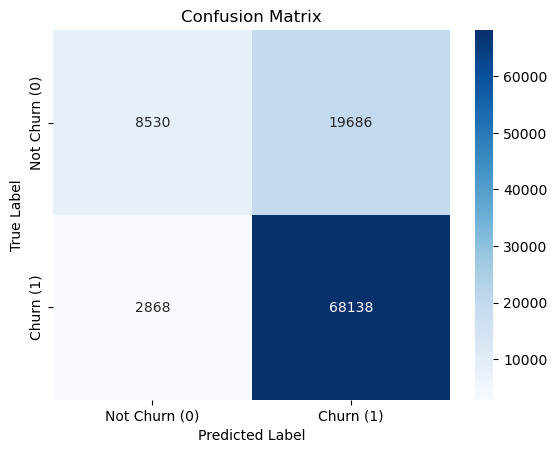

In [43]:
# Predictions
y_pred_cat = model_cat.predict(X_train)

# Churn Probabilty
prob_cat = model_cat.predict_proba(X_train) # Output : array([0.xxx, 0.xxx])
y_prob_cat = prob_cat[:,1] 

# Evaluation
eval_metrics(y_train, y_pred_cat, y_prob_cat)

ROC AUC Score: 0.7276839244751365
Best Threshold (Max F1) 0.4515768118462934
Best Threshold (Closest to (0,1)): 0.7691265042480891


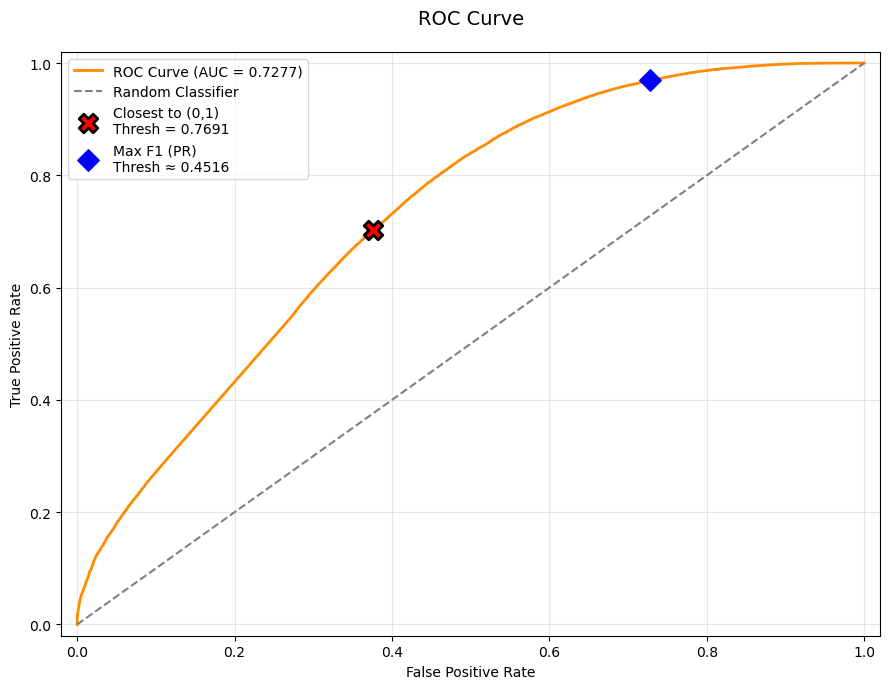

In [44]:
thresh_f1_cat, thresh_corner_cat = optimal_threshold(y_train, y_prob_cat)

Accuracy      : 0.7710185241176352
Precision     : 0.7702735984237865
Recall        : 0.9690307861307496
F1-score      : 0.8582958075018399
ROC-AUC       : 0.7276839244751365


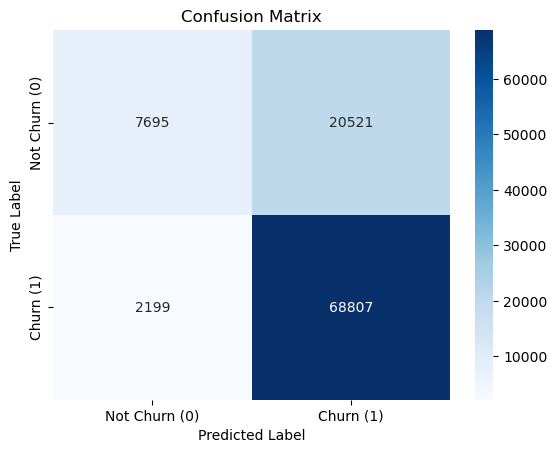

In [45]:
y_pred_f1_cat = (y_prob_cat >= thresh_f1_cat).astype(int)

eval_metrics(y_train, y_pred_f1_cat, y_prob_cat)

Accuracy      : 0.6798391485759206
Precision     : 0.8246917666528755
Recall        : 0.7017998479001775
F1-score      : 0.7582990314309409
ROC-AUC       : 0.7276839244751365


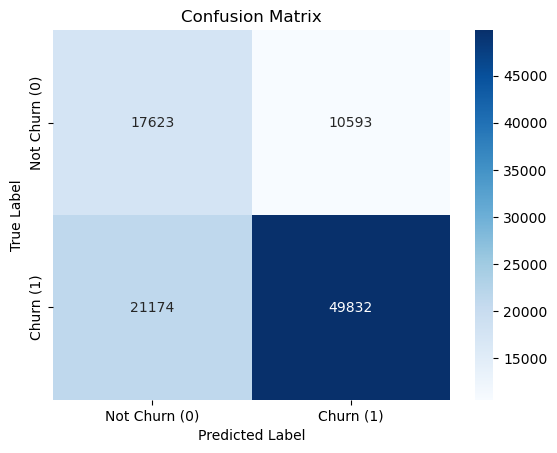

In [46]:
y_pred_corner_cat = (y_prob_cat >= thresh_corner_cat).astype(int)

eval_metrics(y_train, y_pred_corner_cat, y_prob_cat)

Accuracy      : 0.6397388348014217
Precision     : 0.6334704955349326
Recall        : 0.9382740063541464
F1-score      : 0.7563174536807171
ROC-AUC       : 0.6200174508178236


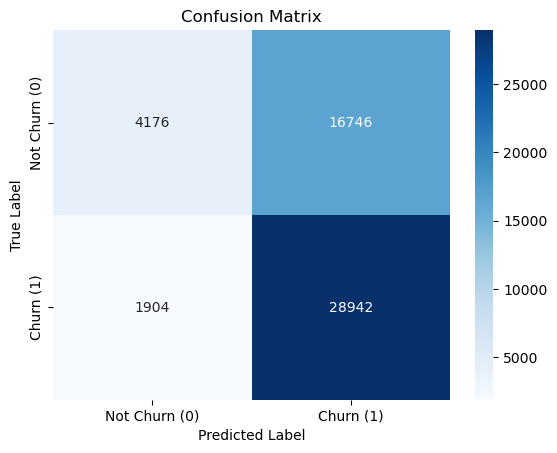

In [47]:
y_prob_test_cat = model_cat.predict_proba(X_test)[:,1] 
y_pred_test_cat = (y_prob_test_cat>= thresh_f1_cat).astype(int)

eval_metrics(y_test, y_pred_test_cat, y_prob_test_cat)

In [48]:
joblib.dump(
    {"model": model_cat, "threshold": thresh_f1_cat}, 
    '../models/cat_and_threshold.pkl'
)

['../models/cat_and_threshold.pkl']

## Summary

In [49]:
y_pred_all = [y_pred_test, y_pred_test_xgb, y_pred_test_lgbm, y_pred_test_cat]
y_prob_all = [y_prob_test, y_prob_test_xgb, y_prob_test_lgbm, y_prob_test_cat]


summary = {
    "Model": ["LogisticRegression", "XGBClassifier","LGBMClassifier","CatBoostClassifier"],
    "ROC-AUC": [roc_auc_score(y_test, y_prob) for y_prob in y_prob_all],
    "F1-Score": [f1_score(y_test, y_pred) for y_pred in y_pred_all],
    "Recall": [recall_score(y_test, y_pred) for y_pred in y_pred_all],
    "Precision":[precision_score(y_test, y_pred) for y_pred in y_pred_all],
    "Accuracy": [accuracy_score(y_test, y_pred) for y_pred in y_pred_all]
        }
summary = pd.DataFrame(summary)
summary.set_index("Model", inplace=True)
summary

,ROC-AUC,F1-Score,Recall,Precision,Accuracy
Model,,,,,
LogisticRegression,0.565838,0.760904,0.973060,0.624701,0.635624
XGBClassifier,0.614380,0.754367,0.931012,0.634063,0.638734
LGBMClassifier,0.623042,0.759227,0.940997,0.636312,0.644375
CatBoostClassifier,0.620017,0.756317,0.938274,0.633470,0.639739


LGBMClassifier got the best ROC-AUC score.